In [33]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from datetime import datetime
import matplotlib.patches as patches

In [34]:
#DATA SPANNING 1990-2025

unem_new = pd.read_csv("Monthly_Unemployment_Data.csv",  comment='#')
crime_new = pd.read_csv("Monthly_Crime_Data.csv",  comment='#')

print(crime_new.head())
print(unem_new.head())

   Unnamed: 0        Date  Property_Crime  Violent_Crime
0          60  1990-01-01            8829           2385
1          61  1990-02-01            6991           1903
2          62  1990-03-01            7860           2116
3          63  1990-04-01            7648           2105
4          64  1990-05-01            7281           2387
   Unnamed: 0             Series ID  Year Period     Label  Value        Date
0           0  LAUCN261630000000003  1990    M01  1990 Jan    9.1  1990-01-01
1           1  LAUCN261630000000003  1990    M02  1990 Feb    9.2  1990-02-01
2           2  LAUCN261630000000003  1990    M03  1990 Mar    8.9  1990-03-01
3           3  LAUCN261630000000003  1990    M04  1990 Apr    8.4  1990-04-01
4           4  LAUCN261630000000003  1990    M05  1990 May    8.6  1990-05-01


In [35]:
#SPLITTING UP MODELS BY DIFFRERENT TYPES OF CRIME

crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)


crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_vio = (
    crime_ts_new
    .set_index("Date")["Violent_Crime"]
    .resample("MS")
    .sum()
    .rename("violent")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_vio))

print(monthly_counts_vio.head())

Monthly points: 432
                       Date  violent
0 1990-01-01 00:00:00+00:00     2385
1 1990-02-01 00:00:00+00:00     1903
2 1990-03-01 00:00:00+00:00     2116
3 1990-04-01 00:00:00+00:00     2105
4 1990-05-01 00:00:00+00:00     2387


In [36]:
#SPLITTING UP MODELS BY DIFFRERENT TYPES OF CRIME

crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)


crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_prop = (
    crime_ts_new
    .set_index("Date")["Property_Crime"]
    .resample("MS")
    .sum()
    .rename("property")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_prop))

print(monthly_counts_vio.head())

Monthly points: 432
                       Date  violent
0 1990-01-01 00:00:00+00:00     2385
1 1990-02-01 00:00:00+00:00     1903
2 1990-03-01 00:00:00+00:00     2116
3 1990-04-01 00:00:00+00:00     2105
4 1990-05-01 00:00:00+00:00     2387


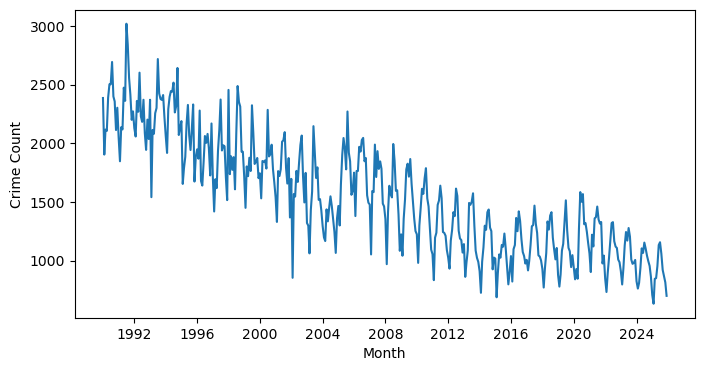

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_counts_vio['Date'], monthly_counts_vio['violent'])
plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()

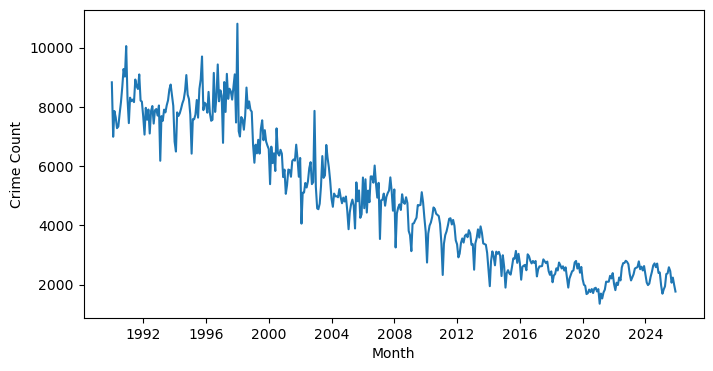

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_counts_prop['Date'], monthly_counts_prop['property'])
plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()

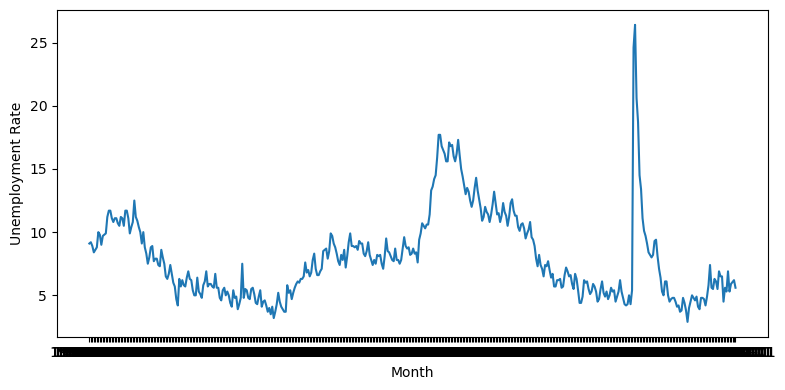

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(unem_new['Date'], unem_new['Value'])
plt.xlabel('Month')
plt.ylabel('Unemployment Rate')
plt.tight_layout()
plt.show()

#not sure whats wrong with the x-axis?? Need to figure out

In [40]:
# #CROSS CORRELATION
# x = monthly_counts_new["total"] - monthly_counts_new["total"].mean()
# y = unem_new["Value"] - unem_new["Value"].mean()

# x_pre = x.loc[:362]
# y_pre = y.loc[:362]

# x_pre_sd = x_pre.diff(12).dropna()
# y_pre_sd = y_pre.diff(12).dropna()

# plt.figure(figsize=(6, 4))
# plt.xcorr(y_pre_sd, x_pre_sd, maxlags=48, normed=True)

# plt.axhline(0, color="black", linewidth=0.8)
# plt.xlabel("Lag (months)")
# plt.ylabel("Cross-correlation")
# plt.show()

In [41]:
#SPLITTING UP MODELS BY DIFFRERENT TYPES OF CRIME

crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)


crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_vio = (
    crime_ts_new
    .set_index("Date")["Violent_Crime"]
    .resample("MS")
    .sum()
    .rename("violent")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_vio))

print(monthly_counts_vio.head())

Monthly points: 432
                       Date  violent
0 1990-01-01 00:00:00+00:00     2385
1 1990-02-01 00:00:00+00:00     1903
2 1990-03-01 00:00:00+00:00     2116
3 1990-04-01 00:00:00+00:00     2105
4 1990-05-01 00:00:00+00:00     2387


In [42]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts_vio["covid"] = np.select(
    [
        monthly_counts_vio["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts_vio["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_vio["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts_vio["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts_vio["covid"] = pd.Categorical(
    monthly_counts_vio["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

X = pd.get_dummies(monthly_counts_vio["covid"], drop_first=True).astype(float)


#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts_prop["covid"] = np.select(
    [
        monthly_counts_prop["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts_prop["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_prop["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts_prop["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts_prop["covid"] = pd.Categorical(
    monthly_counts_prop["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

X = pd.get_dummies(monthly_counts_prop["covid"], drop_first=True).astype(float)

In [43]:
# y (violent)
y_prop = monthly_counts_prop["property"].copy()
y_prop.index = pd.date_range("1990-01-01", periods=len(y_prop), freq="MS")

idx_dt = y_prop.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

t = np.arange(len(exog), dtype=float)
t = (t - t.mean()) / t.std()
exog["t"] = t
exog["t_during"] = t * exog["during"]
exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y_prop.rename("y"), exog], axis=1).dropna()
y_aligned_prop = df0["y"]
X_aligned_prop = df0.drop(columns="y")

print(df0.shape)
print(y_aligned_prop.head())

(432, 7)
1990-01-01    8829
1990-02-01    6991
1990-03-01    7860
1990-04-01    7648
1990-05-01    7281
Freq: MS, Name: y, dtype: int64


In [44]:
# #creating a covid indicator var
# #0 pre covid, 1 during covid, 2 post covid

# monthly_counts_vio["covid"] = np.select(
#     [
#         monthly_counts_vio["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
#         (monthly_counts_vio["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_vio["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
#         monthly_counts_vio["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
#     ],
#     ["pre", "during", "post"],
#     default="unknown" 
# )



# monthly_counts_vio["covid"] = pd.Categorical(
#     monthly_counts_vio["covid"],
#     categories=["pre", "during", "post"],
#     ordered=True
# )

# X = pd.get_dummies(monthly_counts_vio["covid"], drop_first=True).astype(float)


# #creating a covid indicator var
# #0 pre covid, 1 during covid, 2 post covid

# monthly_counts_prop["covid"] = np.select(
#     [
#         monthly_counts_prop["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
#         (monthly_counts_prop["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_prop["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
#         monthly_counts_prop["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
#     ],
#     ["pre", "during", "post"],
#     default="unknown" 
# )



# monthly_counts_prop["covid"] = pd.Categorical(
#     monthly_counts_prop["covid"],
#     categories=["pre", "during", "post"],
#     ordered=True
# )

# X = pd.get_dummies(monthly_counts_prop["covid"], drop_first=True).astype(float)

In [45]:

y = monthly_counts_vio["violent"].copy()
y.index = pd.date_range("1990-01-01", periods=len(y), freq="MS")

idx_dt = y.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

# t = np.arange(len(exog), dtype=float)
# t = (t - t.mean()) / t.std()
# exog["t"] = t
# exog["t_during"] = t * exog["during"]
# exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y.rename("y"), exog], axis=1).dropna()
y_aligned = df0["y"]
X_aligned = df0.drop(columns="y")

print(df0.shape)
print(y_aligned.head())

(432, 4)
1990-01-01    2385
1990-02-01    1903
1990-03-01    2116
1990-04-01    2105
1990-05-01    2387
Freq: MS, Name: y, dtype: int64


In [46]:
new_mod = SARIMAX(
    np.log(y_aligned),
    exog=X_aligned,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    trend="ct"
).fit(disp=False)

print(new_mod.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  432
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                  38.560
Date:                            Wed, 18 Feb 2026   AIC                            -57.120
Time:                                    17:20:58   BIC                            -16.436
Sample:                                01-01-1990   HQIC                           -41.058
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.2732      0.111      2.465      0.014       0.056       0.490
drift            -0.0003  

AR roots: [1.10111946]
MA roots: [7.7379099]


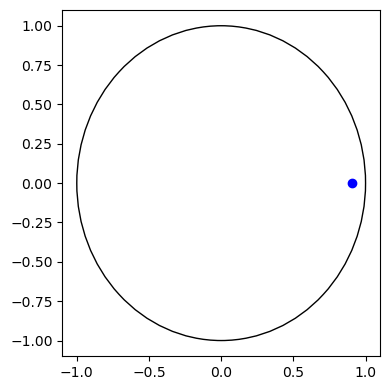

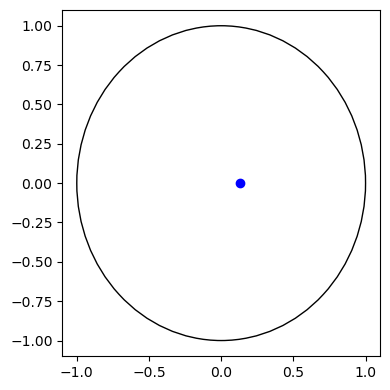

In [47]:
#NON SEASONAL ROOTS
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()


ma_pars = new_mod.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,-ma_pars]) 
print(f"MA roots: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ma_roots), np.imag(inv_ma_roots), color='blue', marker='o', label="Inverse MA Roots")

plt.tight_layout()
plt.show()

Seasonal AR roots: [-1.03600537e+00+0.j         -8.97206969e-01+0.51800268j
 -8.97206969e-01-0.51800268j -5.18002685e-01+0.89720697j
 -5.18002685e-01-0.89720697j  2.84473668e-16+1.03600537j
  2.84473668e-16-1.03600537j  5.18002685e-01+0.89720697j
  5.18002685e-01-0.89720697j  1.03600537e+00+0.j
  8.97206969e-01+0.51800268j  8.97206969e-01-0.51800268j]


C:\Users\enora\AppData\Local\Temp\ipykernel_50708\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


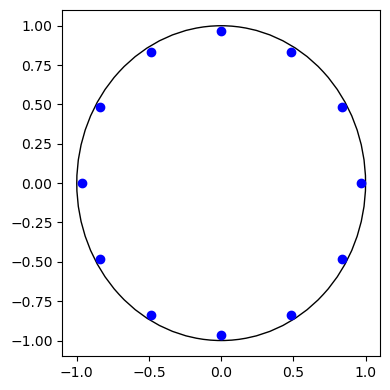

In [48]:
#SEASONAL ROOTS
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

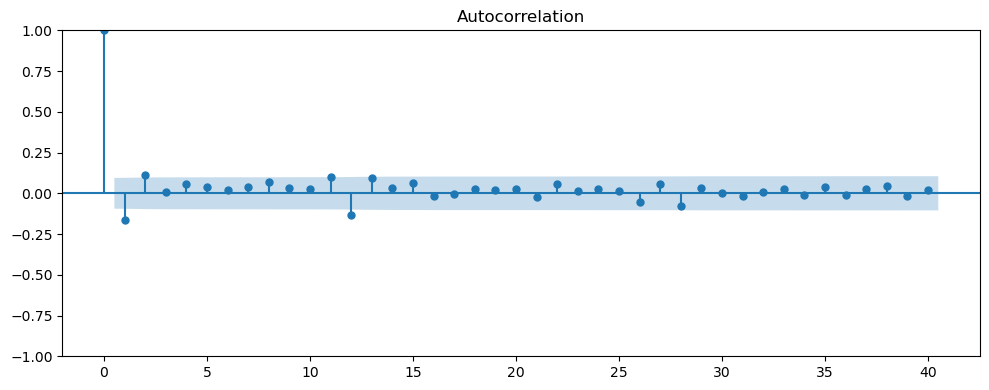

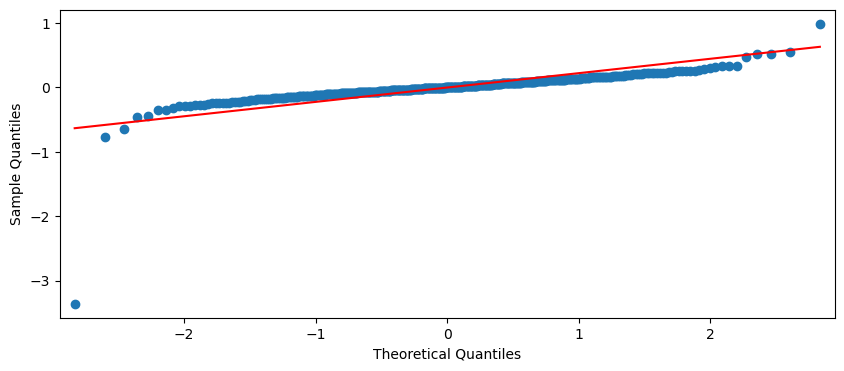

In [49]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids, line='s', ax=ax)
plt.show()

In [50]:

y = monthly_counts_prop["property"].copy()
y.index = pd.date_range("1990-01-01", periods=len(y), freq="MS")

idx_dt = y.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

#t = np.arange(len(exog), dtype=float)
#t = (t - t.mean()) / t.std()
#exog["t"] = t
#exog["t_during"] = t * exog["during"]
#exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y.rename("y"), exog], axis=1).dropna()
y_aligned = df0["y"]
X_aligned = df0.drop(columns="y")

print(df0.shape)
print(y_aligned.head())

(432, 4)
1990-01-01    8829
1990-02-01    6991
1990-03-01    7860
1990-04-01    7648
1990-05-01    7281
Freq: MS, Name: y, dtype: int64


In [51]:
new_mod = SARIMAX(
    np.log(y_aligned),
    exog=X_aligned,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="ct"
).fit(disp=False)

print(new_mod.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  432
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                 -21.079
Date:                             Wed, 18 Feb 2026   AIC                             60.159
Time:                                     17:21:01   BIC                             96.774
Sample:                                 01-01-1990   HQIC                            74.614
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.3462      0.110      3.162      0.002       0.132       0.561
drift            -

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.09949478]
MA roots: [12.28418888]


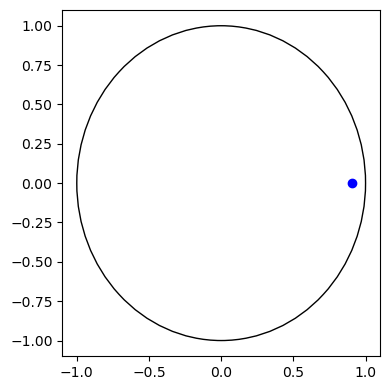

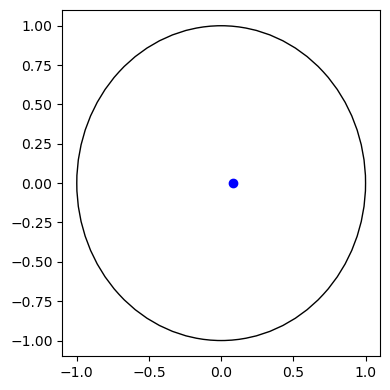

In [52]:
#NON SEASONAL ROOTS
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()


ma_pars = new_mod.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,-ma_pars]) 
print(f"MA roots: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ma_roots), np.imag(inv_ma_roots), color='blue', marker='o', label="Inverse MA Roots")

plt.tight_layout()
plt.show()

Seasonal AR roots: [-1.04791224e+00+0.j         -9.07518619e-01+0.52395612j
 -9.07518619e-01-0.52395612j -5.23956119e-01+0.90751862j
 -5.23956119e-01-0.90751862j -2.29848281e-16+1.04791224j
 -2.29848281e-16-1.04791224j  5.23956119e-01+0.90751862j
  5.23956119e-01-0.90751862j  1.04791224e+00+0.j
  9.07518619e-01+0.52395612j  9.07518619e-01-0.52395612j]


C:\Users\enora\AppData\Local\Temp\ipykernel_50708\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


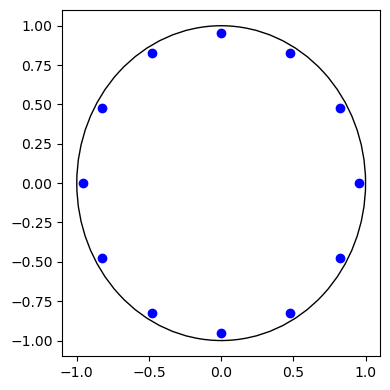

In [53]:
#SEASONAL ROOTS
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

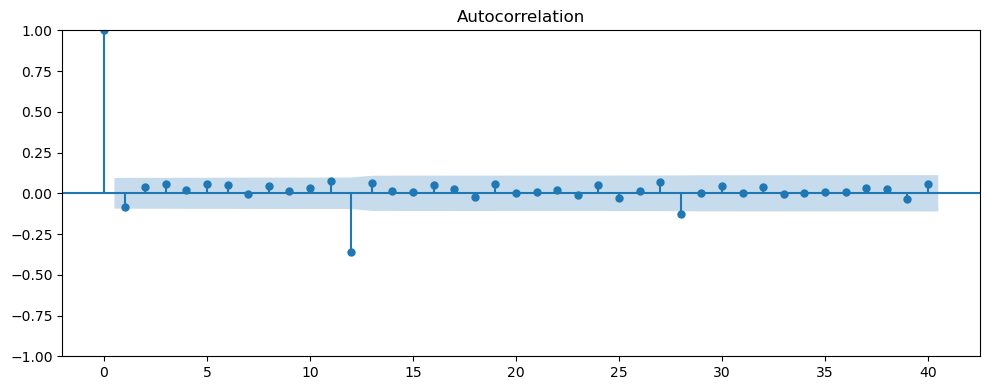

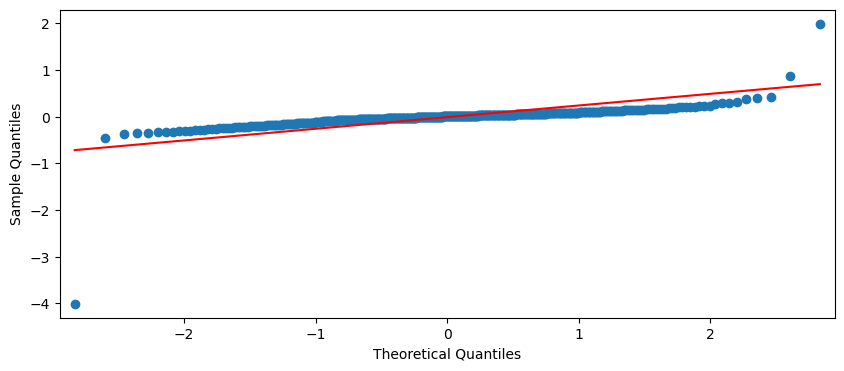

In [54]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids, line='s', ax=ax)
plt.show()